In [ ]:
# BASIC STEPS

!pip install transformers
!pip install opencv-python
!pip install tensorboard
!pip install timm
import albumentations as A
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
from torchvision import models, transforms
import time
from transformers import CLIPModel, CLIPProcessor, ViTModel, ViTFeatureExtractor
import numpy as np
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
from timm import create_model
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import shutil
import random
from pathlib import Path




from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [ ]:
# Convert ISIC 2019 Training Data to Binary

# Paths
csv_path = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_GroundTruth.csv'
img_dir = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input'
output_dir = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input'

# Create output folders
mel_dir = os.path.join(output_dir, 'Melanoma')
ben_dir = os.path.join(output_dir, 'Benign')
os.makedirs(mel_dir, exist_ok=True)
os.makedirs(ben_dir, exist_ok=True)

# Load ground truth
df = pd.read_csv(csv_path)

# Iterate and move
moved = {'Melanoma': 0, 'Benign': 0}
for idx, row in df.iterrows():
    image_id = row['image']
    is_melanoma = row['MEL'] == 1
    file_name = image_id + ".jpg"
    src_path = os.path.join(img_dir, file_name)

    if not os.path.exists(src_path):
        print(f"Missing: {src_path}")
        continue

    dst_path = os.path.join(mel_dir if is_melanoma else ben_dir, file_name)
    shutil.move(src_path, dst_path)
    moved['Melanoma' if is_melanoma else 'Benign'] += 1

print(f"Done. Moved {moved['Melanoma']} melanoma images and {moved['Benign']} benign images.")



Done. Moved 4522 melanoma images and 20809 benign images.


In [ ]:
# Counting for Checking

# Base path where your split dataset is stored
mel_dir = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input/Melanoma'
ben_dir = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input/Benign'

# Count function
def count_images(folder):
    valid_exts = ('.jpg', '.jpeg', '.png')
    return len([f for f in os.listdir(folder) if f.lower().endswith(valid_exts)])

# Count and print
mel_count = count_images(mel_dir)
ben_count = count_images(ben_dir)

print(f"Melanoma: {mel_count}")
print(f"Benign: {ben_count}")

Melanoma: 20809
Benign: 20809


In [ ]:
# Augmentation for ISIC 2019 Training Set


# CONFIG
melanoma_dir = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input/Melanoma"
metadata_path = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_GroundTruth.csv'
image_ext = ".jpg"

# LOAD METADATA
metadata_df = pd.read_csv(metadata_path, delimiter='\t' if '\t' in open(metadata_path).readline() else ',')  # auto-detect delimiter

melanoma_df = metadata_df[metadata_df['MEL'] == 1]
original_count = len(melanoma_df)
target_count = 20809
needed_augments = target_count - original_count
aug_per_image = (needed_augments // original_count) + 1

print(f"Original Melanoma Images: {original_count}")
print(f"Target: {target_count} → Need to generate {needed_augments} new samples (≈ {aug_per_image} per image)\n")

# AUGMENTATION TRANSFORMS
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=10, p=0.5),
    A.Resize(224, 224),
])

# AUGMENT AND SAVE
new_rows = []
counter = 0

for _, row in tqdm(melanoma_df.iterrows(), total=original_count):
    image_id = row['image']
    original_path = os.path.join(melanoma_dir, f"{image_id}{image_ext}")
    image = cv2.imread(original_path)
    if image is None:
        print(f"Could not read {original_path}")
        continue

    for i in range(aug_per_image):
        if counter >= needed_augments:
            break

        augmented = transform(image=image)['image']
        new_id = f"{image_id}_aug{i}"
        save_path = os.path.join(melanoma_dir, f"{new_id}{image_ext}")
        cv2.imwrite(save_path, augmented)

        # Construct new metadata row
        new_row = {col: 0 for col in metadata_df.columns}
        new_row['image'] = new_id
        new_row['MEL'] = 1
        new_rows.append(new_row)
        counter += 1

    if counter >= needed_augments:
        break

# APPEND TO METADATA
augmented_df = pd.DataFrame(new_rows)
combined_df = pd.concat([metadata_df, augmented_df], ignore_index=True)

# SAVE FINAL METADATA
combined_df.to_csv(metadata_path, index=False)

print(f"\n{counter} augmented melanoma images added.")
print(f"Metadata updated at: {metadata_path}")



/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:111: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Original Melanoma Images: 4522
Target: 20809 → Need to generate 16287 new samples (≈ 4 per image)



 90%|█████████ | 4071/4522 [1:35:39<10:35,  1.41s/it]



16287 augmented melanoma images added.
Metadata updated at: /content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_GroundTruth.csv


In [ ]:
# Normalize ISIC 2019 Images

import os
import cv2
import numpy as np
from tqdm import tqdm

# Config
input_root = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input'
output_root = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized'
image_size = (224, 224)
valid_exts = ('.jpg', '.png', '.jpeg')

mel_dir = os.path.join(input_root, 'Melanoma')
ben_dir = os.path.join(input_root, 'Benign')

# Create output directories
os.makedirs(os.path.join(output_root, 'Melanoma'), exist_ok=True)
os.makedirs(os.path.join(output_root, 'Benign'), exist_ok=True)

# Normalize function
def normalize_and_save(cls):
    input_dir = os.path.join(input_root, cls)
    output_dir_cls = os.path.join(output_root, cls)

    for fname in tqdm(os.listdir(input_dir), desc=f'Processing {cls}'):
        if not fname.lower().endswith(valid_exts):
            continue
        input_path = os.path.join(input_dir, fname)
        output_path = os.path.join(output_dir_cls, fname)

        image = cv2.imread(input_path)
        if image is None:
            print(f"Could not read: {input_path}")
            continue

        # Resize
        image = cv2.resize(image, image_size)

        # BGR → RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Normalize to [0, 1]
        image = image.astype(np.float32) / 255.0

        # Save as uint8 (for storage); training will divide by 255 again
        save_image = (image * 255).astype(np.uint8)
        save_image = cv2.cvtColor(save_image, cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, save_image)

# Run for both classes
normalize_and_save('Melanoma')
normalize_and_save('Benign')

print(f"\nNormalized images saved to: {output_root}")



Processing Benign: 100%|██████████| 20809/20809 [6:36:42<00:00,  1.14s/it]


Normalized images saved to: /content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized


Total: 86424 | Train: 73461 | Val: 12963


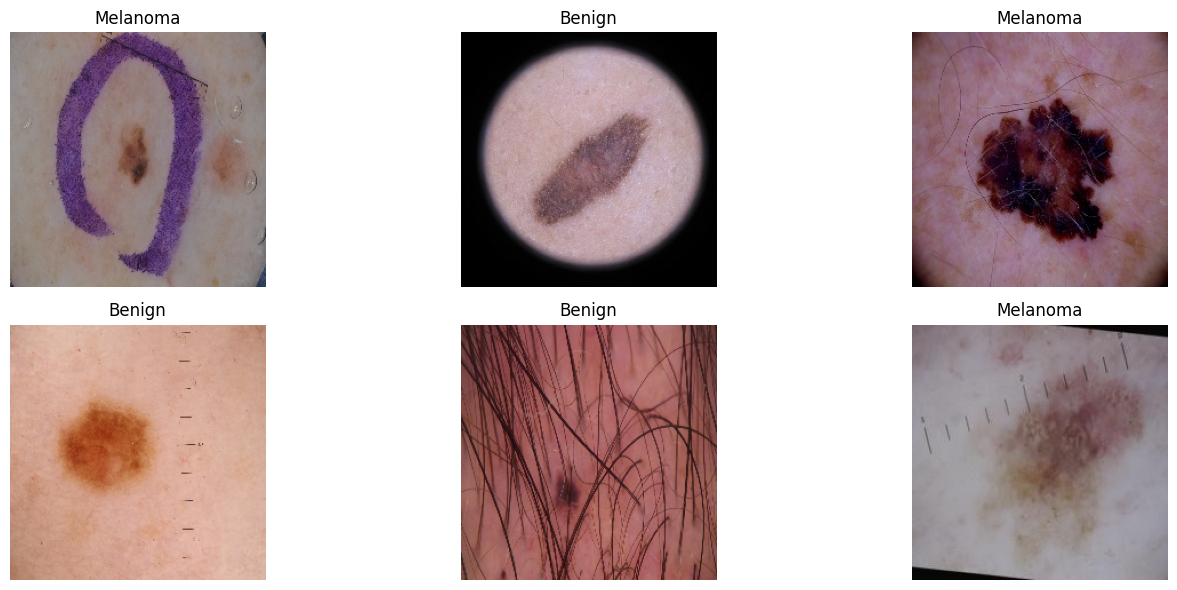

ISIC 2020 images: 44806
ISIC 2019 images: 41618
Combined total: 86424


In [ ]:
# Loading Data

from torch.utils.data import random_split
from glob import glob
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Config
ISIC_2020_PATH = '/content/drive/MyDrive/THESIS/Dataset/kaggle/train'
ISIC_2019_PATH = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized'
BATCH_SIZE = 128
IMG_SIZE = 224
NUM_WORKERS = 12
VAL_SPLIT = 0.15
CLASS_NAMES = ['Benign', 'Melanoma']

# Dataset Class
class ISICCombinedDataset(Dataset):
    def __init__(self, isic2020_root, isic2019_root, transform=None):
        self.samples = []
        self.transform = transform

        # Add ISIC 2020 samples
        for label, cls in enumerate(CLASS_NAMES):
            folder = os.path.join(isic2020_root, cls)
            image_paths = glob(os.path.join(folder, '*.jpg'))
            self.samples += [(img_path, label) for img_path in image_paths]

        # Add ISIC 2019 samples
        for label, cls in enumerate(CLASS_NAMES):
            folder = os.path.join(isic2019_root, cls)
            image_paths = glob(os.path.join(folder, '*.jpg'))
            self.samples += [(img_path, label) for img_path in image_paths]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = cv2.imread(path)  # uint8, 0-255
        if image is None:
            raise RuntimeError(f"Could not read image at {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']  # Albumentations expects uint8 input

        return image, torch.tensor(label, dtype=torch.long)


# Transforms
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Load dataset
combined_dataset = ISICCombinedDataset(
    isic2020_root=ISIC_2020_PATH,
    isic2019_root=ISIC_2019_PATH,
    transform=transform
)

# Train/Val Split
total_size = len(combined_dataset)
val_size = int(total_size * VAL_SPLIT)
train_size = total_size - val_size

train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Total: {total_size} | Train: {train_size} | Val: {val_size}")

# Visualization
def denormalize(image_tensor):
    image_tensor = image_tensor * 0.5 + 0.5  # reverse Normalize(mean=0.5, std=0.5)
    return image_tensor.clamp(0, 1)

def visualize_samples(dataset, num_images=6):
    indices = random.sample(range(len(dataset)), num_images)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img = denormalize(img_tensor).permute(1, 2, 0).numpy()
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(CLASS_NAMES[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# View samples from training set
visualize_samples(train_dataset)

def count_images(path, classes=['Benign','Melanoma']):
    total = 0
    for cls in classes:
        folder = os.path.join(path, cls)
        total += len([f for f in os.listdir(folder) if f.lower().endswith('.jpg')])
    return total

print("ISIC 2020 images:", count_images(ISIC_2020_PATH))
print("ISIC 2019 images:", count_images(ISIC_2019_PATH))
print("Combined total:", count_images(ISIC_2020_PATH) + count_images(ISIC_2019_PATH))


In [ ]:
# LETS GO BERSERK!
# On ISIC2020 and ISIC2019!
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        # EfficientNetB4 Backbone va Extract features from the penultimate layer
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])  # It removes classifier (keeps features)

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers to prevent them from training
        for param in self.resnet_feat.parameters():
            param.requires_grad = False

        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False

        for param in self.densenet_feat.parameters():
            param.requires_grad = False

        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate the total input size dynamically for the fully connected layer
        fc_input_size = 0

        # Function to calculate the feature size from a model
        def calculate_fc_input_size(model, dummy_input):
            with torch.no_grad():
                output = model(dummy_input)
                # If the model output is a list, get the first tensor
                if isinstance(output, list):
                    output = output[0]
                output = self.global_pool(output)
                output = torch.flatten(output, 1)
                return output.shape[1]

        # Create a dummy input to calculate the feature sizes
        dummy_input = torch.randn(1, 3, 224, 224)  # Create a dummy input

        # Calculate the input size for each backbone
        fc_input_size += calculate_fc_input_size(self.resnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.efficientnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.densenet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.swin_feat, dummy_input)

        # Calculate the total input size for the fully connected layer
        fc_input_size = 2048 + 1792 + 1920 + 7

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from ResNet
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        # Extract features from EfficientNet
        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        # Extract features from DenseNet
        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        # Extract features from Swin Transformer
        swin_feats = self.swin_feat(x)[-1]        # Get last feature map
        swin_out = self.global_pool(swin_feats)   # (B, C, 1, 1)
        swin_out = torch.flatten(swin_out, 1)     # Now (B, C)

        # Concatenate all features
        combined_features = torch.cat(
            (resnet_out, efficientnet_out, densenet_out, swin_out), dim=1
        )

        # Classification head
        out = self.fc(combined_features)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate model
num_classes = 2
model = Berserker(num_classes=num_classes).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-4, weight_decay=1e-4)  # Only FC head params are trainable

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

# Paths and vars for checkpointing
CHECKPOINT_PATH = "/content/drive/MyDrive/THESIS/Dataset/kaggle/best_19and20_train.pth"
start_epoch = 0
best_val_loss = float('inf')

# Load checkpoint if exists (for resume)
if os.path.exists(CHECKPOINT_PATH):
    print("Loading checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    print(f"Resumed from epoch {start_epoch}, best_val_loss: {best_val_loss:.4f}")

# Training function
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc


# Training loop
num_epochs = 10

for epoch in range(start_epoch, num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)

    # Save checkpoint if val loss improves
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"Validation loss improved to {val_loss:.4f}, saving checkpoint...")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
        }, CHECKPOINT_PATH)
        print(f"Checkpoint saved at {CHECKPOINT_PATH}")

print("Training complete.")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 232MB/s]


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Epoch 1/10


...

Train Loss: 0.1313 | Train Acc: 0.9469
Val Loss: 0.1422 | Val Acc: 0.9394
Validation loss improved to 0.1422, saving checkpoint...
Checkpoint saved at /content/drive/MyDrive/THESIS/Dataset/kaggle/best_19and20_train.pth
Epoch 9/10


Validation: 100%|██████████| 102/102 [04:47<00:00,  2.82s/it]


Train Loss: 0.1222 | Train Acc: 0.9508
Val Loss: 0.1410 | Val Acc: 0.9431
Validation loss improved to 0.1410, saving checkpoint...
Checkpoint saved at /content/drive/MyDrive/THESIS/Dataset/kaggle/best_19and20_train.pth
Epoch 10/10


Validation: 100%|██████████| 102/102 [04:47<00:00,  2.82s/it]


Train Loss: 0.1148 | Train Acc: 0.9545
Val Loss: 0.1370 | Val Acc: 0.9427
Validation loss improved to 0.1370, saving checkpoint...
Checkpoint saved at /content/drive/MyDrive/THESIS/Dataset/kaggle/best_19and20_train.pth
Training complete.


In [ ]:
# Normalizing ISIC 2019 Test Dataset

import os
import cv2
import numpy as np
from tqdm import tqdm

# Config
input_root = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Input'
output_root = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Normalized'
image_size = (224, 224)
valid_exts = ('.jpg', '.png', '.jpeg')

# Create output directories
os.makedirs(os.path.join(output_root, 'Melanoma'), exist_ok=True)
os.makedirs(os.path.join(output_root, 'Other'), exist_ok=True)

def normalize_and_save(cls):
    input_dir = os.path.join(input_root, cls)
    output_dir_cls = os.path.join(output_root, cls)

    for fname in tqdm(os.listdir(input_dir), desc=f'Processing {cls}'):
        if not fname.lower().endswith(valid_exts):
            continue
        input_path = os.path.join(input_dir, fname)
        output_path = os.path.join(output_dir_cls, fname)

        image = cv2.imread(input_path)
        if image is None:
            print(f"Could not read: {input_path}")
            continue

        # Resize to 224x224
        image = cv2.resize(image, image_size)

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Normalize to [0, 1] for model input (temporarily)
        image = image.astype(np.float32) / 255.0

        # Save as uint8 image with RGB values back in [0, 255]
        save_image = (image * 255).astype(np.uint8)
        save_image = cv2.cvtColor(save_image, cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, save_image)

# Process both classes
normalize_and_save('Melanoma')
normalize_and_save('Other')

print(f"\nNormalized test images saved to: {output_root}")



Processing Other: 100%|██████████| 5528/5528 [06:37<00:00, 13.92it/s]


Normalized test images saved to: /content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Normalized


Test set size: 6580


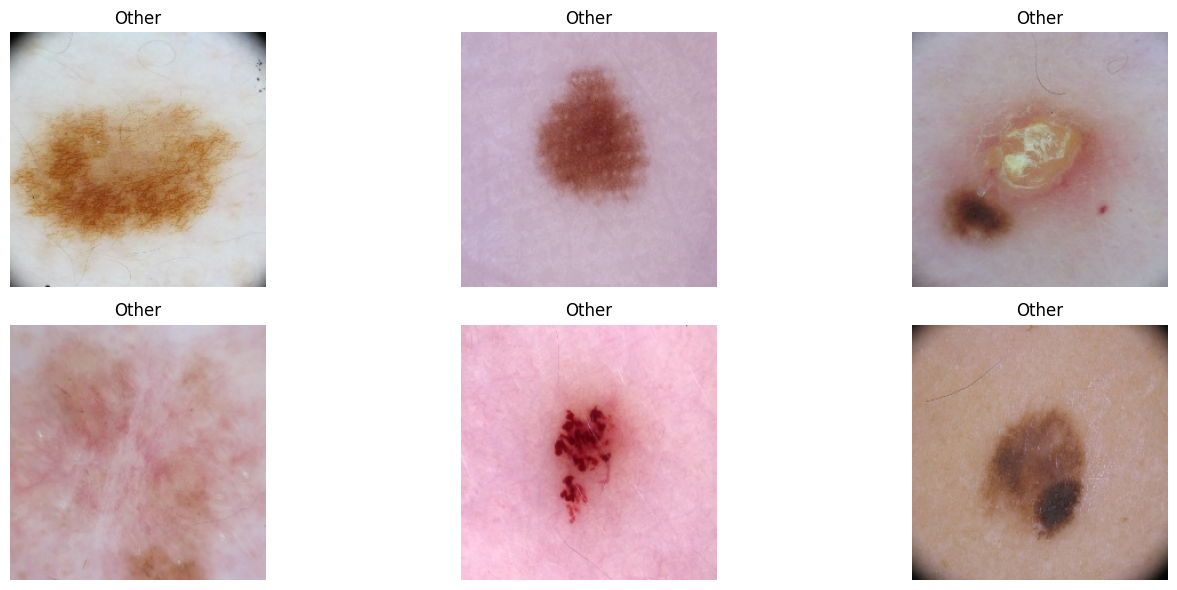

In [ ]:
# Test Dataset Loader

# Required Imports

from glob import glob
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuration
ISIC_2019_TEST_PATH = '/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Test/ISIC_2019_Test_Normalized'
BATCH_SIZE = 128
IMG_SIZE = 224
NUM_WORKERS = 8
TEST_CLASS_NAMES = ['Other', 'Melanoma']  # label 0 = Other, 1 = Melanoma

# Transform (Matches training setup: [0,255] → [0,1] → [-1,1])
test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Dataset Class
class ISIC2019TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for label, cls in enumerate(TEST_CLASS_NAMES):
            cls_dir = os.path.join(root_dir, cls)
            image_paths = glob(os.path.join(cls_dir, '*.jpg'))
            self.samples += [(img_path, label) for img_path in image_paths]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = cv2.imread(path)
        if image is None:
            raise RuntimeError(f"Could not read image at {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)

# DataLoader
test_dataset = ISIC2019TestDataset(root_dir=ISIC_2019_TEST_PATH, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Test set size: {len(test_dataset)}")

# Denormalization (for visualization only)
def denormalize(tensor):
    tensor = tensor * 0.5 + 0.5
    return tensor.clamp(0, 1)

# Visualize Random Samples
def visualize_test_samples(dataset, num_images=6):
    indices = random.sample(range(len(dataset)), num_images)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img = denormalize(img_tensor).permute(1, 2, 0).numpy()
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(TEST_CLASS_NAMES[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# View Some Samples
visualize_test_samples(test_dataset)



Testing: 100%|██████████| 52/52 [02:21<00:00,  2.72s/it]



Test Accuracy: 0.8444
Precision: 0.5104
Recall (Sensitivity): 0.6540
F1 Score: 0.5733

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.88      0.90      5528
    Melanoma       0.51      0.65      0.57      1052

    accuracy                           0.84      6580
   macro avg       0.72      0.77      0.74      6580
weighted avg       0.86      0.84      0.85      6580


Confusion Matrix:
[[4868  660]
 [ 364  688]]


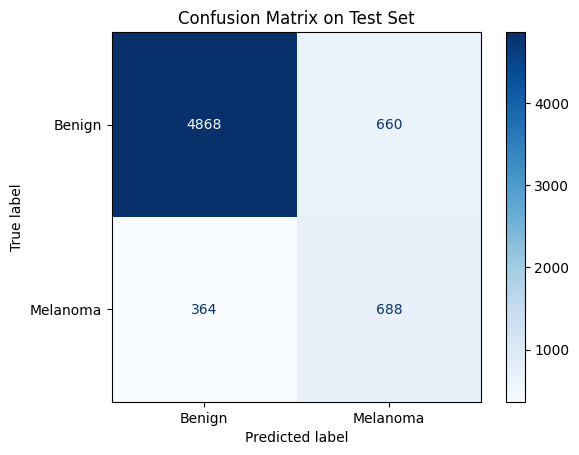

AUC: 0.8698


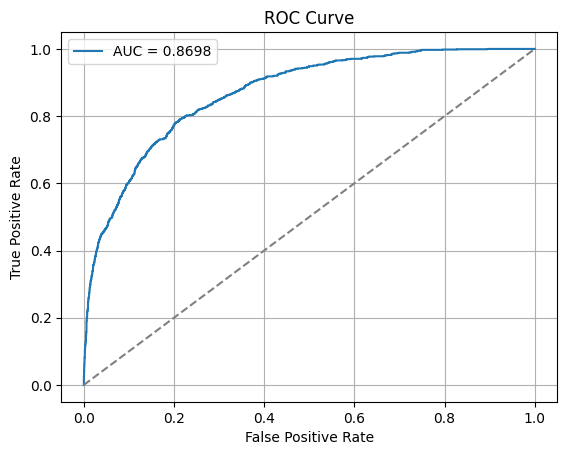

In [ ]:
# Testing on ISIC 2019 Test Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Berserker(num_classes=2)
model.to(device)

best_checkpoint_path = "/content/drive/MyDrive/THESIS/Dataset/kaggle/best_19and20_train.pth"
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        threshold = 0.43
        probs = torch.softmax(outputs, dim=1)         # probs[:, 1] = melanoma prob

        # Apply threshold on melanoma probability:
        preds = (probs[:, 1] > threshold).long()

        all_probs.extend(probs[:, 1].cpu().numpy())        # Probabilities for class 1 (Melanoma)
        all_preds.extend(preds.cpu().numpy())              # Predicted classes
        all_labels.extend(labels.cpu().numpy())            # Ground truth labels

# Set averaging method based on output shape
average_type = 'binary' if model.fc[-1].out_features == 2 else 'weighted'

# Metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=average_type, zero_division=0)
recall = recall_score(all_labels, all_preds, average=average_type, zero_division=0)
f1 = f1_score(all_labels, all_preds, average=average_type, zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

# Display Metrics
print(f"\nTest Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Melanoma"]))
print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Melanoma"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.savefig("confusion_matrix_test.png")
plt.show()

# AUC Calculation (for binary classification)
if model.fc[-1].out_features == 2:
    auc = roc_auc_score(all_labels, all_probs)
    print(f"AUC: {auc:.4f}")

    # Optional: Plot ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig("roc_curve_test.png")
    plt.show()


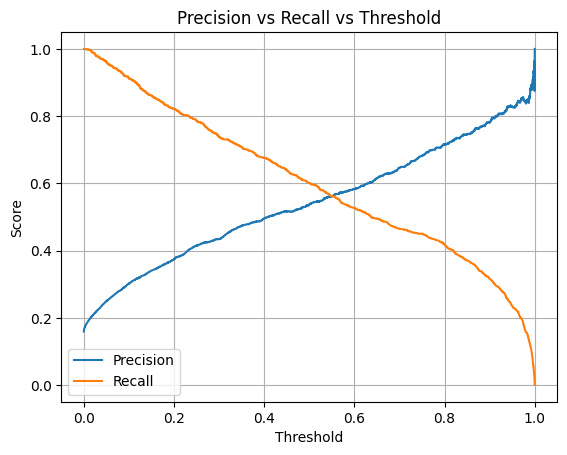

Best F1 score: 0.5747 at threshold 0.43


In [ ]:
from sklearn.metrics import precision_recall_curve
from numpy import argmax


precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()



f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = argmax(f1_scores)
print(f"Best F1 score: {f1_scores[best_idx]:.4f} at threshold {thresholds[best_idx]:.2f}")


Testing: 100%|██████████| 52/52 [07:06<00:00,  8.20s/it]



Test Accuracy: 0.8495
Precision: 0.5234
Recall (Sensitivity): 0.6597
F1 Score: 0.5837

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.89      0.91      5528
    Melanoma       0.52      0.66      0.58      1052

    accuracy                           0.85      6580
   macro avg       0.73      0.77      0.75      6580
weighted avg       0.87      0.85      0.86      6580


Confusion Matrix:
[[4896  632]
 [ 358  694]]


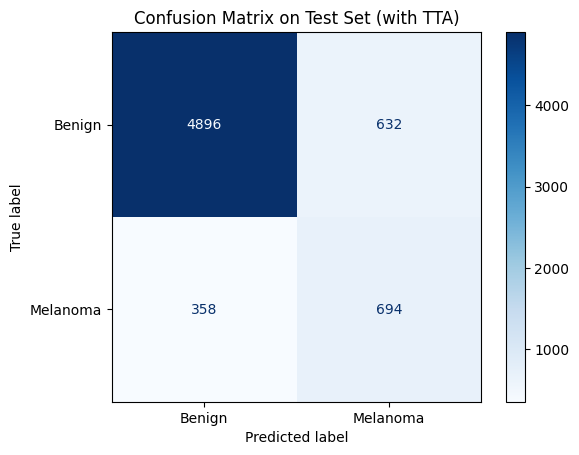

AUC: 0.8800


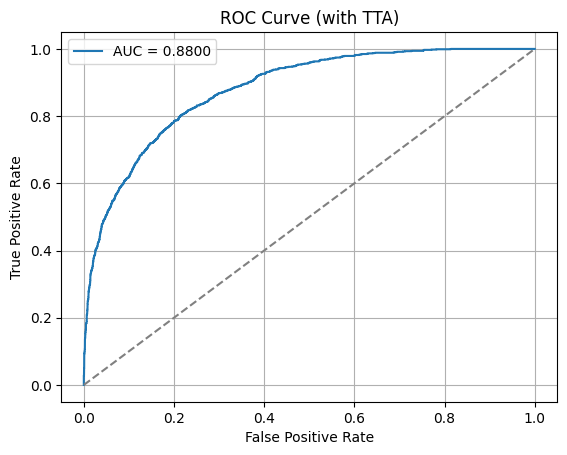

In [ ]:
# Testing with TTA on ISIS 2019 Test Dataset

import torchvision.transforms as T
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Berserker(num_classes=2)
model.to(device)

best_checkpoint_path = "/content/drive/MyDrive/THESIS/Dataset/kaggle/best_19and20_train.pth"
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# transforms
tta_transforms = [
    T.Compose([]),  # original
    T.Compose([T.RandomHorizontalFlip(p=1.0)]),
    T.Compose([T.RandomVerticalFlip(p=1.0)]),
]

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)

        batch_size = images.size(0)
        probs_tta = torch.zeros(batch_size, 2).to(device)  # for accumulating TTA probs

        # Apply each TTA transform on the batch
        for transform in tta_transforms:
            # Transform expects PIL Image or Tensor in [C,H,W], here images are tensors.
            # Since images come as batches, apply transform per image
            augmented_images = torch.stack([transform(img.cpu()) for img in images]).to(device)

            outputs = model(augmented_images)
            probs = torch.softmax(outputs, dim=1)
            probs_tta += probs

        probs_tta /= len(tta_transforms)  # average probs over all TTA versions

        threshold = 0.43  # threshold for melanoma prob
        preds = (probs_tta[:, 1] > threshold).long()

        all_probs.extend(probs_tta[:, 1].cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Set averaging method based on output shape
average_type = 'binary' if model.fc[-1].out_features == 2 else 'weighted'

# Metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=average_type, zero_division=0)
recall = recall_score(all_labels, all_preds, average=average_type, zero_division=0)
f1 = f1_score(all_labels, all_preds, average=average_type, zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Melanoma"]))
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Melanoma"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set (with TTA)")
plt.savefig("confusion_matrix_test_tta.png")
plt.show()

if model.fc[-1].out_features == 2:
    auc = roc_auc_score(all_labels, all_probs)
    print(f"AUC: {auc:.4f}")

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (with TTA)")
    plt.legend()
    plt.grid(True)
    plt.savefig("roc_curve_test_tta.png")
    plt.show()
